# COMP 579 - Assignment 2 

Prepared by: Nicolas Smits

Presented to: Prof. Isabeau Premont Schwartz, Farnoosh Faraji


## Task 1: Tabular RL

In [8]:
import gym
import numpy as np
import matplotlib.pyplot as plt
from gym.wrappers import StepAPICompatibility

print(gym.__version__)

import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_


0.26.2


In [9]:
# softmax function with temperature
def softmax(x, temp):
    e_x = np.exp(x / temp)
    return e_x / e_x.sum()


In [24]:
# SARSA learning algorithm class
class Sarsa:
    def __init__(self, env, alpha, gamma, temp):
        self.env = env # environment
        self.alpha = alpha # learning rate
        self.gamma = gamma # discount factor
        self.temp = temp # temperature
        self.Q = np.zeros((env.observation_space.n, env.action_space.n)) # Q table (action-value function)

    # select action based on epsilon-greedy policy
    def select_action(self, s, greedy=False):
        if greedy:
            # if finished training, then choose the optimal policy
            if self.temp == 0:
                return np.argmax(self.Q[s])
            return np.random.choice(self.env.action_space.n, p=softmax(self.Q[s], self.temp))
        else:
            return np.random.choice(self.env.action_space.n, p=softmax(self.Q[s], self.temp))

    # update Q table
    def update(self, s, a, r, s_, a_):
        target = r + self.gamma * self.Q[s_, a_] # target value
        prediction = self.Q[s, a] # prediction value (current Q value)
        self.Q[s, a] += self.alpha * (target - prediction) # update Q value
        return


# bonus question, optional
class Hybrid_Sarsa_Q:
  def __init__(self, env, alpha, gamma, temp):
    # write your solution here
    self.env = None
    self.alpha = None
    self.gamma = None
    self.temp = None
    self.Q = None
    return

  def select_action(self, s, greedy=False):
    # write your solution here
    if greedy:
      # if finished training, then choose the optimal policy
      return
    else:
      return

  def update(self, s, a, r, s_prime, a_prime, done):
    # write your solution here
    return      
  

In [25]:
env_name = 'FrozenLake-v1'
env = gym.make(env_name)
env = StepAPICompatibility(env)
print("Action space:", env.action_space)
print("State space:", env.observation_space)


Action space: Discrete(4)
State space: Discrete(16)


For each experiment (hyperparamter combination), do 10 independent trials. 

Each trial consists of 500 segments. 

In each segment, there are 10 episodes of training, followed by 1 testing episode where you run the optimal policy so far (i.e. pick actions greedily). 

In other words, there are 5500 episodes in each trial. Pick at least 3 settings of the temperature parameter used in the exploration and at least 3 settings of the learning rate.

In [29]:
# function that runs each episode
def run_episode(env, agent, greedy=False):
    """
    Run an episode of the environment
    --------------------
    Parameters:
        env: gym environment
        agent: agent class
        greedy: boolean to choose greedy policy or not (testing episode)
    Returns:
        None
    """
    s, _ = env.reset() # reset environment
    a = agent.select_action(s, greedy) # select action
    total_reward = 0
    done = False
    while not done:
        result = env.step(a)
        
        # Newer API: (observation, reward, terminated, truncated, info)
        s_, r_, terminated, truncated, info = result
        done = terminated or truncated # check if episode is done
        
        a_ = agent.select_action(s_, greedy) # select next action
        agent.update(s, a, r_, s_, a_) # SARSA Q table update
        # update state and action
        s = s_
        a = a_
        total_reward += r_
    return total_reward

# function that runs each hyperparameter combination
def run_hyperparameters(env, alphas, gamma, temps, trials, segments):
    """
    Run experiments with different hyperparameters on the given environment.
    --------------------
    Parameters:
        env: gym environment
        alphas: a single value or list of learning rates
        gamma: discount factor
        temps: a single value or list of temperatures
        segments: tuple of (num_segments, num_train_episodes, num_test_episodes)
    Returns:
        train_results: numpy array of shape (len(alphas), len(temps), num_segments * num_train_episodes)
        test_results: numpy array of shape (len(alphas), len(temps), num_segments * num_test_episodes)
    """
    # ensure alphas and temps are lists
    if not isinstance(alphas, (list, np.ndarray)):
        alphas = [alphas]
    if not isinstance(temps, (list, np.ndarray)):
        temps = [temps]
    
    # unpack segments 
    num_segments, num_train_eps, num_test_eps = segments
    total_train_eps = num_segments * num_train_eps
    total_test_eps  = num_segments * num_test_eps
    
    # initialize results arrays
    train_results = np.zeros((len(alphas), len(temps), trials, total_train_eps))
    test_results  = np.zeros((len(alphas), len(temps), trials, total_test_eps))
    
    # loop over hyperparameters and trials.
    for i, alpha in enumerate(alphas):
        for j, temp in enumerate(temps):
            for t in range(trials):
                agent = Sarsa(env, alpha, gamma, temp)
                train_ep_counter = 0
                test_ep_counter = 0
                for seg in range(num_segments):
                    # Run training episodes in this segment.
                    for tr_ep in range(num_train_eps):
                        reward = run_episode(env, agent, greedy=False)
                        train_results[i, j, t, train_ep_counter] = reward
                        train_ep_counter += 1
                    # Run one testing episode (greedy).
                    reward = run_episode(env, agent, greedy=True)
                    test_results[i, j, t, test_ep_counter] = reward
                    test_ep_counter += 1
    return train_results, test_results


## Experiments

In [ ]:
# Set hyperparameter values:
alphas = [0.1, 0.25, 0.5, 0.75, 0.9] # learning rate settings
temps  = [0.005, 0.01, 0.015, 0.02,  0.025] # temperature settings
gamma  = 0.99 # discount factor
trials = 10 # 10 independent trials
segments = (500, 10, 1) # 500 segments: each segment = 10 training eps + 1 test ep


In [49]:
# Run experiments
train_results, test_results = run_hyperparameters(env, alphas, gamma, temps, trials, segments)

In [50]:
# smoothing function to better visualize the results
def smooth_data(y, k=1):
    """
    Smooths the 1D array y using a simple moving average of window size 2k+1.
    Returns an array of the same length as y.
    
    Parameters:
        y: 1D numpy array
        k: int, window size
    """
    n = len(y)
    y_smoothed = np.zeros_like(y, dtype=float)
    for i in range(n):
        # The window is [i-k, i+k], clipped to [0, n-1]
        start = max(0, i - k)
        end = min(n, i + k + 1)
        y_smoothed[i] = np.mean(y[start:end])
    return y_smoothed

### Experiment 1 - Changing Learning Rate $\alpha$
In one graph, the x-axis shows the alpha (learning rate), and the y-axis shows the return
of the agent (averaged over the last 10 training episodes and the 10 runs). The graph should
have at least 3 lines (for 3 temperature values).

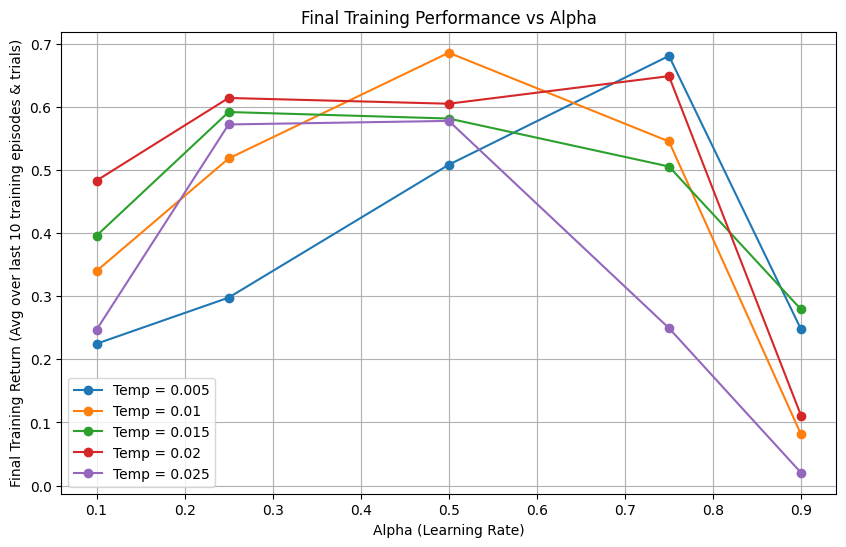

In [51]:
# Graph 1:
# x-axis: Alpha, y-axis: Final training performance (avg over last 10 training episodes & trials)
final_train_avg = np.zeros((len(alphas), len(temps)))
for i in range(len(alphas)):
    for j in range(len(temps)):
        trial_avgs = []
        for t in range(trials):
            # 1) Extract the entire training history for this trial:
            train_series = train_results[i, j, t, :]  # shape = (total_train_eps,)
            
            # 2) Smooth the series:
            smoothed_series = smooth_data(train_series, k=5)  # choose k as desired
            
            # 3) Take the average of the last 10 episodes in the *smoothed* series:
            last_10 = smoothed_series[-10:]
            trial_avgs.append(np.mean(last_10))

        # 4) Average across trials:
        final_train_avg[i, j] = np.mean(trial_avgs)

plt.figure(figsize=(10,6))
for j, temp in enumerate(temps):
    plt.plot(alphas, final_train_avg[:, j], marker='o', label=f'Temp = {temp}')
plt.xlabel('Alpha (Learning Rate)')
plt.ylabel('Final Training Return (Avg over last 10 training episodes & trials)')
plt.title('Final Training Performance vs Alpha')
plt.legend()
plt.grid(True)
plt.show()


### Experiment 2 - Changing Temperature, T
In the second graph, the x-axis shows the temperature, and the y-axis shows the return of
the agent (averaged over the last 10 training episodes and the 10 runs). The graph should have
at least 3 lines (for 3 learning rates)

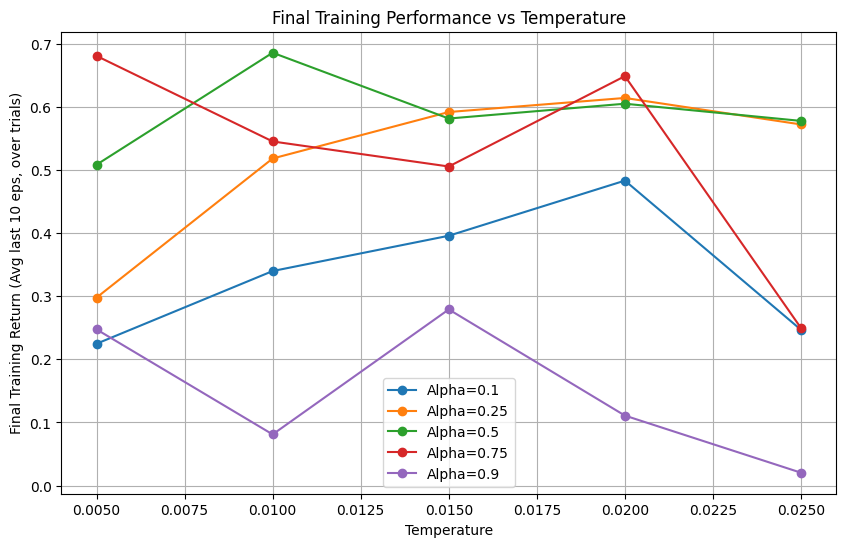

In [52]:
# final_train_avg_temp will be shape (n_alphas, n_temps)
final_train_avg_temp = np.zeros((len(alphas), len(temps)))

for i, alpha in enumerate(alphas):
    for j, temp in enumerate(temps):
        trial_avgs = []
        for t in range(trials):
            # Extract all training episodes for this trial
            train_series = train_results[i, j, t, :]  # shape: (total_train_eps,)
            
            # Optionally smooth the entire training series
            smoothed_series = smooth_data(train_series, k=5)
            
            # Take the average of the last 10 episodes in the (smoothed) series
            last_10 = smoothed_series[-10:]
            trial_avgs.append(np.mean(last_10))
        
        # Average across all trials
        final_train_avg_temp[i, j] = np.mean(trial_avgs)

plt.figure(figsize=(10, 6))
for i, alpha in enumerate(alphas):
    # Plot final training performance vs temperature for each alpha
    plt.plot(temps, final_train_avg_temp[i, :], marker='o', label=f'Alpha={alpha}')

plt.xlabel('Temperature')
plt.ylabel('Final Training Return (Avg last 10 eps, over trials)')
plt.title('Final Training Performance vs Temperature')
plt.legend()
plt.grid(True)
plt.show()

### Experiment 3 - Training Reward vs Number of Episodes
In the third graph, show the training reward as a function of the number of episodes. There should be 9 lines in total, one for each of temperature/alpha combinations

In [ ]:
# extract the top N hyperparameter combinations
n_alphas = len(alphas)
n_temps = len(temps)
final_train_avg = np.zeros((n_alphas, n_temps))

# compute final performance for each (alpha, temp) pair (as a metric to evaluate "best" performance)
for i in range(n_alphas):
    for j in range(n_temps):
        trial_avgs = []
        for t in range(trials):
            train_series = train_results[i, j, t, :]  # full training reward series for one trial
            # smooth for visualization
            smoothed_series = smooth_data(train_series, k=5)
            # average
            last_10 = smoothed_series[-10:]
            trial_avgs.append(np.mean(last_10))
        final_train_avg[i, j] = np.mean(trial_avgs)

# top N hyperparameter combinations to plot
num_to_plot = 5  

# list of index pairs corresponding to each (alpha, temp) combination
indices = [(i, j) for i in range(n_alphas) for j in range(n_temps)]
# flatten
flat_perf = final_train_avg.flatten()
# get the indices of the top-performing combinations
best_flat_indices = np.argsort(flat_perf)[-num_to_plot:]
# convert these back to (i, j) pairs
best_indices = [indices[k] for k in best_flat_indices]

print("Best hyperparameter combinations (alpha index, temp index):", best_indices)


Best hyperparameter combinations (alpha index, temp index): [(2, 3), (1, 3), (3, 3), (3, 0), (2, 1)]


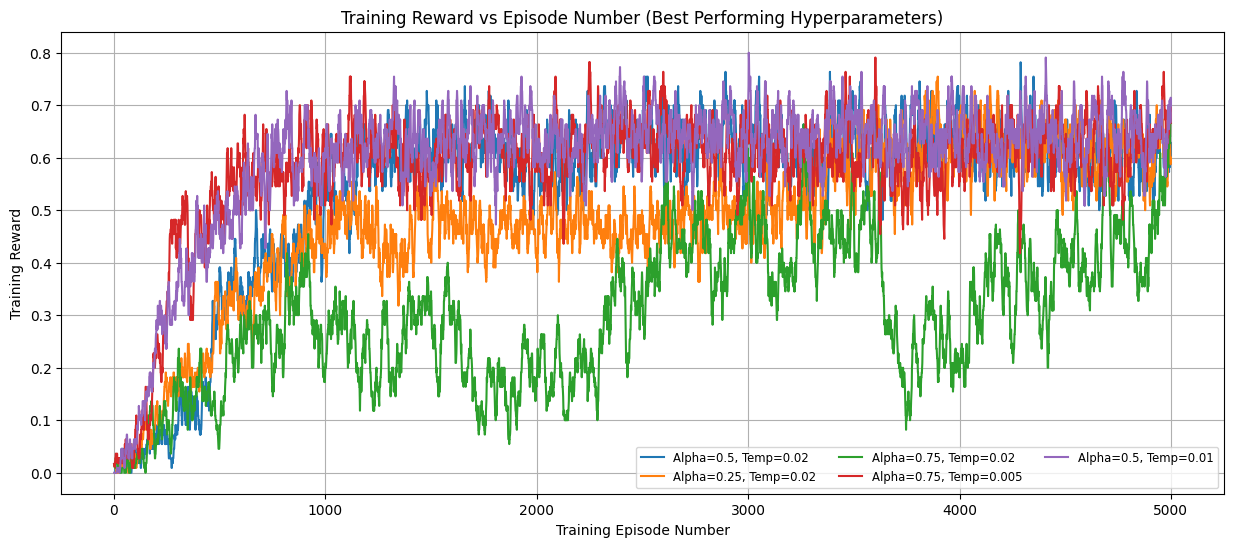

In [ ]:
# Experiment 3: Training Reward vs Episode Number (only for best combinations)
plt.figure(figsize=(15, 6))
num_train_eps = train_results.shape[-1]  # total training episodes per trial
for (i, j) in best_indices:
    # Average the training reward over the trials
    all_runs = train_results[i, j, :, :]  # shape: (trials, total_train_eps)
    mean_over_trials = np.mean(all_runs, axis=0)
    smoothed_mean = smooth_data(mean_over_trials, k=5)
    episodes = np.arange(1, num_train_eps + 1)
    label_str = f"Alpha={alphas[i]}, Temp={temps[j]}"
    plt.plot(episodes, smoothed_mean, label=label_str)
plt.xlabel('Training Episode Number')
plt.ylabel('Training Reward')
plt.title('Training Reward vs Episode Number (Best Performing Hyperparameters)')
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
plt.show()


### Experiment 4 - Testing Performance
The graph that instead shows the effect of the parameters on the final testing performance. The y-axis should now show the test reward(greedy policy) as a function of the number of the episodes. (There should be 9 lines in total, one for each of temperature/alpha combinations)

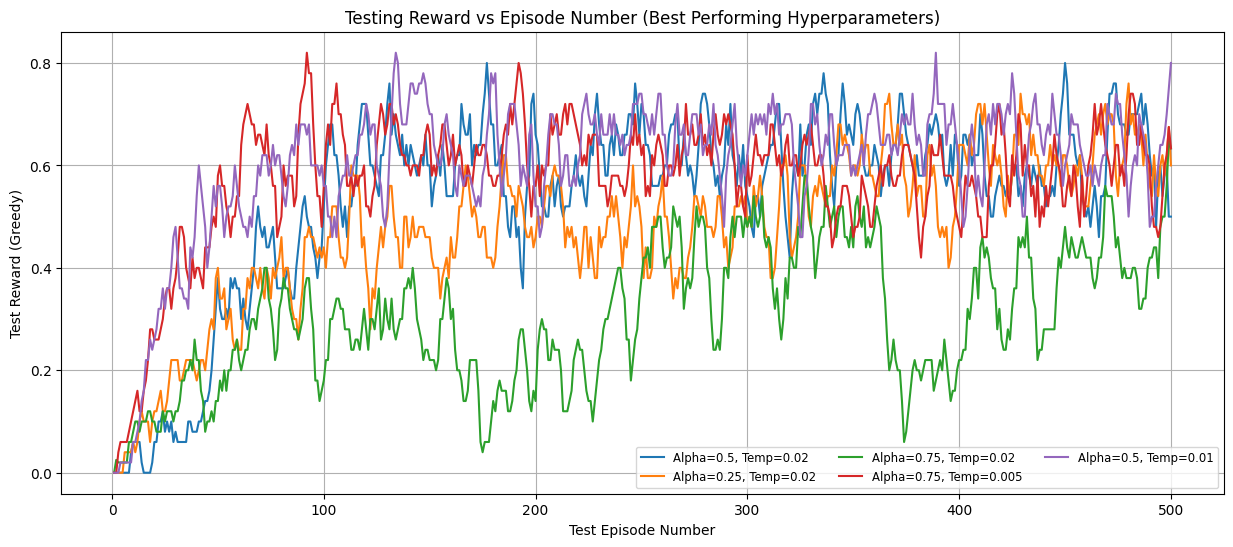

In [62]:
# Experiment 4: Testing Reward vs Episode Number (only for best combinations)
plt.figure(figsize=(15, 6))
num_test_eps = test_results.shape[-1]  # total test episodes per trial
for (i, j) in best_indices:
    all_runs_test = test_results[i, j, :, :]  # shape: (trials, total_test_eps)
    mean_test = np.mean(all_runs_test, axis=0)
    smoothed_test = smooth_data(mean_test, k=2)
    test_episodes = np.arange(1, num_test_eps + 1)
    label_str = f"Alpha={alphas[i]}, Temp={temps[j]}"
    plt.plot(test_episodes, smoothed_test, label=label_str)
plt.xlabel('Test Episode Number')
plt.ylabel('Test Reward (Greedy)')
plt.title('Testing Reward vs Episode Number (Best Performing Hyperparameters)')
plt.legend(ncol=3, fontsize='small')
plt.grid(True)
plt.show()